# Timing against the SVD
Time of the decomposition-free $\mathrm{Sgn}$ (generalized Newton–Schulz with the $\mathrm{bpoly}(D)$ profile, fixed $K_D$, power-iteration scaling) against the SVD-based one, over size $n$, $\sigma_{\min}$, device and $D$. Both routes get the same matrix; each of the `n_reps` repetitions uses a new random matrix of the same size and $\sigma_{\min}$, so the reported std is over matrices. Each timing is paired with the relative Frobenius error against the exact $\mathrm{Sgn}(M)$. Edit the config and rerun; set `devices=["cpu"]` without a GPU.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.svd_timing import SvdTimingConfig, run_svd_timing, time_table, accuracy_table
%matplotlib inline

In [5]:
cfg = SvdTimingConfig(
    sizes=[128, 256, 512], smins=[1e-4], degrees=[1, 2, 3, 4],
    devices=["cpu", "cuda"], n_fixed=512, dtype=torch.float64, eps=None,
    power_iters=10, power_margin=1.1, n_warmup=3, n_reps=20, cpu_threads=None, svd_driver=None, seed=0,
)
res = run_svd_timing(cfg)

n=128 smin=0.0001: 20 matrices
  cpu: svd 1.47 ms | D=1 3.39 ms | D=2 3.05 ms | D=3 3.08 ms | D=4 3.36 ms
  cuda: svd 56.54 ms | D=1 4.66 ms | D=2 4.55 ms | D=3 4.64 ms | D=4 4.92 ms
n=256 smin=0.0001: 20 matrices
  cpu: svd 6.05 ms | D=1 13.44 ms | D=2 13.03 ms | D=3 13.49 ms | D=4 14.55 ms
  cuda: svd 180.70 ms | D=1 39.37 ms | D=2 38.67 ms | D=3 39.21 ms | D=4 42.76 ms
n=512 smin=0.0001: 20 matrices
  cpu: svd 29.58 ms | D=1 80.48 ms | D=2 80.40 ms | D=3 81.49 ms | D=4 88.65 ms
  cuda: svd 1034.58 ms | D=1 210.43 ms | D=2 201.19 ms | D=3 201.99 ms | D=4 219.20 ms


time (s), median ± std over 20 matrices: cpu, smin = 0.0001
n    D=1               D=2                D=3                D=4                SVD              
128  0.00339 ± 0.0016  0.00305 ± 0.00057  0.00308 ± 0.00042  0.00336 ± 0.00045  0.00147 ± 0.00048
256  0.0134 ± 0.00058  0.013 ± 0.001      0.0135 ± 0.001     0.0146 ± 0.0011    0.00605 ± 0.001  
512  0.0805 ± 0.0017   0.0804 ± 0.0011    0.0815 ± 0.0058    0.0886 ± 0.0034    0.0296 ± 0.0042  

relative Frobenius error, mean ± std over 20 matrices, and iterations run K: cpu, smin = 0.0001
     K   n=128               n=256               n=512             
D=1  32  1.09e-13 ± 5.3e-15  1.42e-13 ± 2.1e-15  1.33e-13 ± 1.6e-15
D=2  21  9.63e-14 ± 4.3e-15  1.19e-13 ± 2.4e-15  1.16e-13 ± 1.3e-15
D=3  16  8.94e-14 ± 3.7e-15  1.12e-13 ± 2.7e-15  1.10e-13 ± 1.4e-15
D=4  14  8.70e-14 ± 3.6e-15  1.05e-13 ± 2.2e-15  1.06e-13 ± 1.5e-15
SVD  -   0.00e+00 ± 0.0e+00  0.00e+00 ± 0.0e+00  0.00e+00 ± 0.0e+00

time (s), median ± std over 20 matrices: c

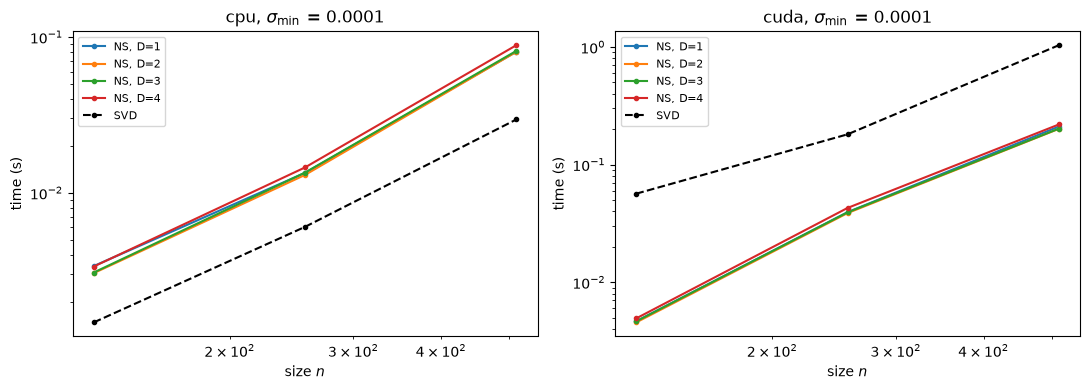

In [6]:
smin_plot = 1e-4  # sigma_min shown in the time-vs-size panels and the tables
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_size(res, device, smin_plot, ax=ax)
fig.tight_layout()
for device in res["cfg"].devices:
    time_table(res, device, smin_plot)
    print()
    accuracy_table(res, device, smin_plot)
    print()

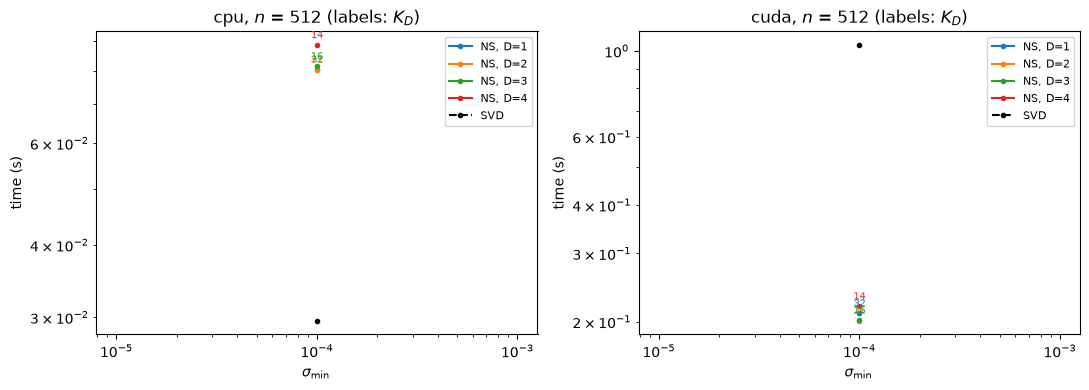

In [7]:
fig, axs = plt.subplots(1, len(res["cfg"].devices), figsize=(5.5 * len(res["cfg"].devices), 4), squeeze=False)
for ax, device in zip(axs[0], res["cfg"].devices):
    plots.plot_time_vs_smin(res, device, ax=ax)
fig.tight_layout()